In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Flatten, Dense, Dropout
from tensorflow.keras.layers import Conv2D
from tensorflow.keras.optimizers import Adam
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from mlxtend.plotting import plot_confusion_matrix
from sklearn.metrics import confusion_matrix
from sklearn.metrics import precision_score, recall_score, accuracy_score
from sklearn.metrics import hamming_loss

In [3]:
file = open("../../datasets/WISDM_ar_v1.1/WISDM_ar_v1.1_raw.txt")
lines = file.readlines()

processedList = []

for i, line in enumerate(lines):
    try:
        line = line.split(",")
        last = line[5].split(";")[0]
        last = last.strip()
        if last == "":
            break
        temp = [line[0], line[1], line[2], line[3], line[4], last]
        processedList.append(temp)
    except Exception:
        print("Error at line number: ", i)

Error at line number:  281873
Error at line number:  281874
Error at line number:  281875


In [4]:
processedList[:100]

[['33', 'Jogging', '49105962326000', '-0.6946377', '12.680544', '0.50395286'],
 ['33', 'Jogging', '49106062271000', '5.012288', '11.264028', '0.95342433'],
 ['33', 'Jogging', '49106112167000', '4.903325', '10.882658', '-0.08172209'],
 ['33', 'Jogging', '49106222305000', '-0.61291564', '18.496431', '3.0237172'],
 ['33', 'Jogging', '49106332290000', '-1.1849703', '12.108489', '7.205164'],
 ['33', 'Jogging', '49106442306000', '1.3756552', '-2.4925237', '-6.510526'],
 ['33', 'Jogging', '49106542312000', '-0.61291564', '10.56939', '5.706926'],
 ['33', 'Jogging', '49106652389000', '-0.50395286', '13.947236', '7.0553403'],
 ['33', 'Jogging', '49106762313000', '-8.430995', '11.413852', '5.134871'],
 ['33', 'Jogging', '49106872299000', '0.95342433', '1.3756552', '1.6480621'],
 ['33', 'Jogging', '49106982315000', '-8.19945', '19.57244', '2.7240696'],
 ['33', 'Jogging', '49107092330000', '1.4165162', '5.7886477', '2.982856'],
 ['33', 'Jogging', '49107202316000', '-1.879608', '-2.982856', '-0.2996

In [5]:
columns = ["user", "activity", "time", "x", "y", "z"]
data = pd.DataFrame(data=processedList, columns=columns)
data.head()

,user,activity,time,x,y,z
0,33,Jogging,49105962326000,-0.6946377,12.680544,0.50395286
1,33,Jogging,49106062271000,5.012288,11.264028,0.95342433
2,33,Jogging,49106112167000,4.903325,10.882658,-0.08172209
3,33,Jogging,49106222305000,-0.61291564,18.496431,3.0237172
4,33,Jogging,49106332290000,-1.1849703,12.108489,7.205164


In [6]:
data.shape

(343416, 6)

In [7]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 343416 entries, 0 to 343415
Data columns (total 6 columns):
 #   Column    Non-Null Count   Dtype
---  ------    --------------   -----
 0   user      343416 non-null  str  
 1   activity  343416 non-null  str  
 2   time      343416 non-null  str  
 3   x         343416 non-null  str  
 4   y         343416 non-null  str  
 5   z         343416 non-null  str  
dtypes: str(6)
memory usage: 15.7 MB


In [8]:
data.isnull().sum()

user        0
activity    0
time        0
x           0
y           0
z           0
dtype: int64

In [9]:
data["x"] = data["x"].astype("float")
data["y"] = data["y"].astype("float")
data["z"] = data["z"].astype("float")

In [10]:
Fs = 20
activities = data["activity"].value_counts().index
activities

Index(['Walking', 'Jogging', 'Upstairs', 'Downstairs', 'Sitting', 'Standing'], dtype='str', name='activity')

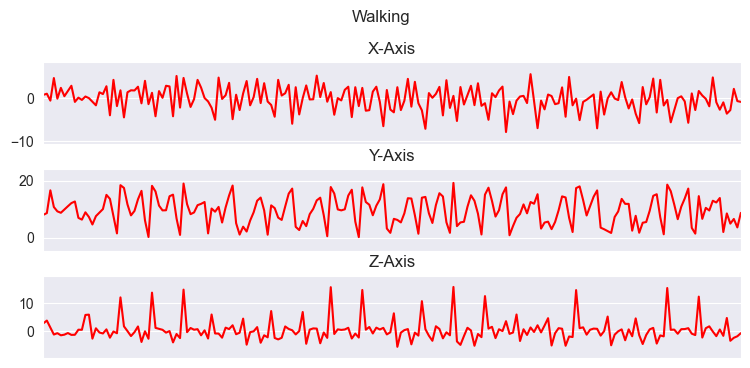

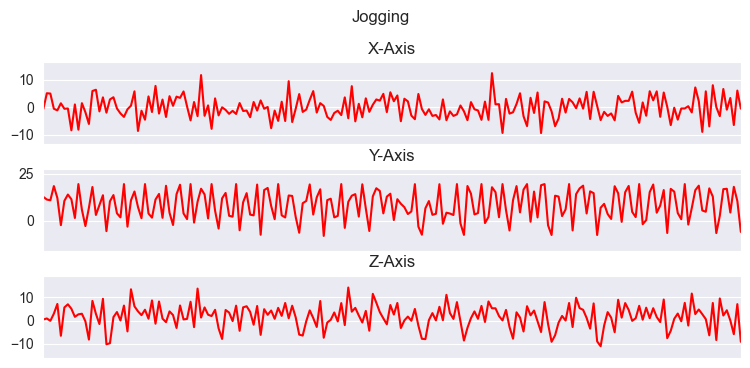

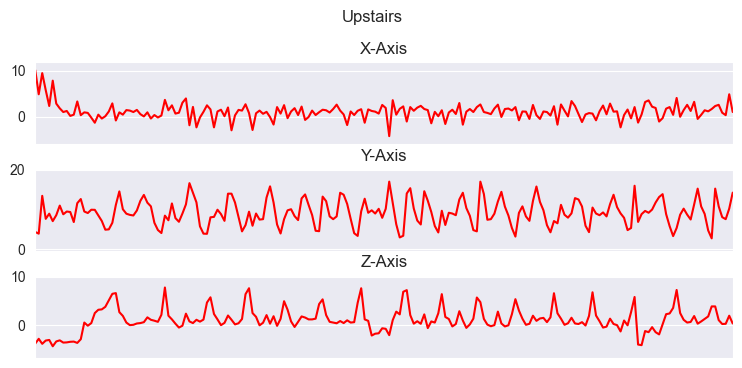

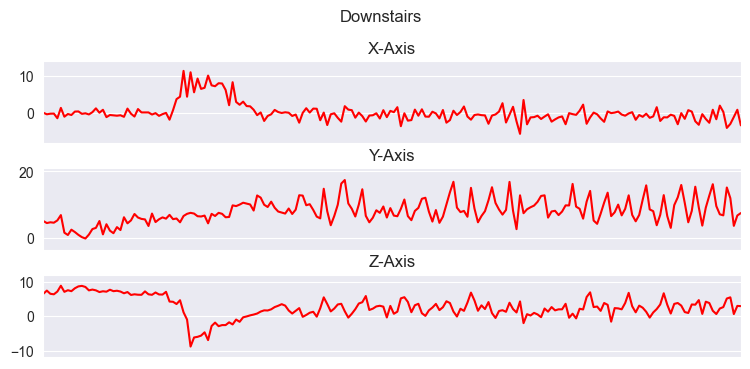

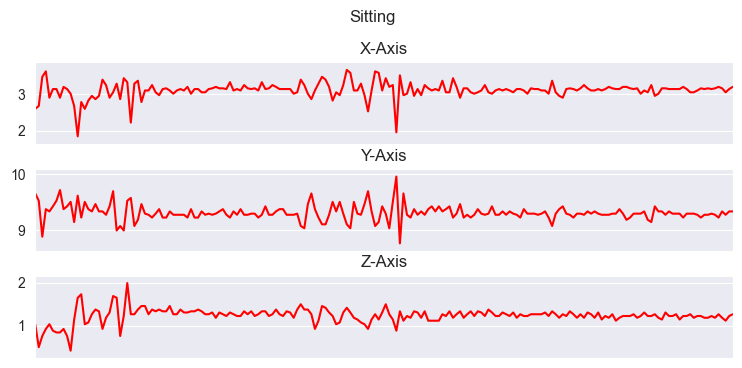

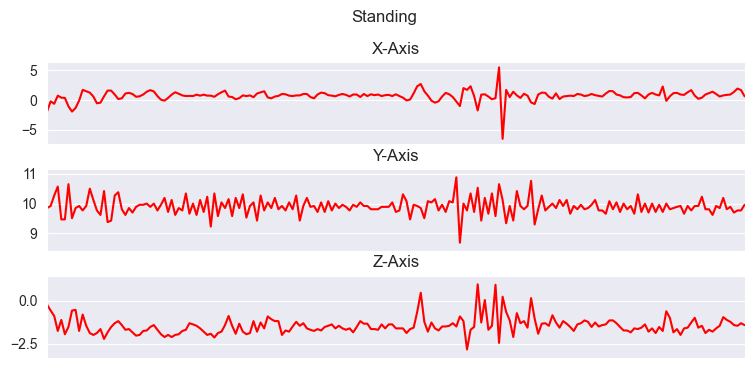

In [11]:
def plot_activity(activity, data):
    fig, (ax0, ax1, ax2) = plt.subplots(nrows=3, figsize=(9, 4), sharex=True)
    plot_axis(ax0, data["time"], data["x"], "X-Axis")
    plot_axis(ax1, data["time"], data["y"], "Y-Axis")
    plot_axis(ax2, data["time"], data["z"], "Z-Axis")
    plt.subplots_adjust(hspace=0.3)
    fig.suptitle(activity)
    plt.subplots_adjust(top=0.85)
    plt.show()


def plot_axis(ax, x, y, title):
    ax.plot(x, y, "r")
    ax.set_title(title)
    ax.xaxis.set_visible(False)
    ax.set_ylim([min(y) - np.std(y), max(y) + np.std(y)])
    ax.set_xlim([min(x), max(x)])
    ax.grid(True)


for activity in activities:
    data_for_plot = data[(data["activity"] == activity)][: Fs * 10]
    plot_activity(activity, data_for_plot)

In [12]:
df = data.drop(["user", "time"], axis=1).copy()
df.head()

,activity,x,y,z
0,Jogging,-0.694638,12.680544,0.503953
1,Jogging,5.012288,11.264028,0.953424
2,Jogging,4.903325,10.882658,-0.081722
3,Jogging,-0.612916,18.496431,3.023717
4,Jogging,-1.184970,12.108489,7.205164


In [13]:
df["activity"].value_counts()

activity
Walking       137375
Jogging       129392
Upstairs       35137
Downstairs     33358
Sitting         4599
Standing        3555
Name: count, dtype: int64

In [14]:
Walking = df[df["activity"] == "Walking"].head(3555).copy()
Jogging = df[df["activity"] == "Jogging"].head(3555).copy()
Upstairs = df[df["activity"] == "Upstairs"].head(3555).copy()
Downstairs = df[df["activity"] == "Downstairs"].head(3555).copy()
Sitting = df[df["activity"] == "Sitting"].head(3555).copy()
Standing = df[df["activity"] == "Standing"].copy()

balanced_data = pd.concat(
    [Walking, Jogging, Upstairs, Downstairs, Sitting, Standing],
    ignore_index=True,
)
balanced_data.shape

(21330, 4)

In [15]:
balanced_data["activity"].value_counts()

activity
Walking       3555
Jogging       3555
Upstairs      3555
Downstairs    3555
Sitting       3555
Standing      3555
Name: count, dtype: int64

In [16]:
balanced_data.head()

,activity,x,y,z
0,Walking,0.844462,8.008764,2.792171
1,Walking,1.116869,8.621680,3.786457
2,Walking,-0.503953,16.657684,1.307553
3,Walking,4.794363,10.760075,-1.184970
4,Walking,-0.040861,9.234595,-0.694638


In [17]:
label = LabelEncoder()
balanced_data["label"] = label.fit_transform(balanced_data["activity"])
balanced_data.head()

,activity,x,y,z,label
0,Walking,0.844462,8.008764,2.792171,5
1,Walking,1.116869,8.621680,3.786457,5
2,Walking,-0.503953,16.657684,1.307553,5
3,Walking,4.794363,10.760075,-1.184970,5
4,Walking,-0.040861,9.234595,-0.694638,5


In [18]:
label.classes_

array(['Downstairs', 'Jogging', 'Sitting', 'Standing', 'Upstairs',
       'Walking'], dtype=object)

In [19]:
X = balanced_data[["x", "y", "z"]]
y = balanced_data["label"]

scaler = StandardScaler()
X = scaler.fit_transform(X)

scaled_X = pd.DataFrame(data=X, columns=["x", "y", "z"])
scaled_X["label"] = y.values

scaled_X.head()

,x,y,z,label
0,0.000503,-0.099190,0.337933,5
1,0.073590,0.020386,0.633446,5
2,-0.361275,1.588160,-0.103312,5
3,1.060258,0.437573,-0.844119,5
4,-0.237028,0.139962,-0.698386,5


In [20]:
Fs = 20
frame_size = Fs * 4  # 80
hop_size = Fs * 2  # 40


def get_frames(df, frame_size, hop_size):

    N_FEATURES = 3

    frames = []
    labels = []
    for i in range(0, len(df) - frame_size, hop_size):
        x = df["x"].values[i : i + frame_size]
        y = df["y"].values[i : i + frame_size]
        z = df["z"].values[i : i + frame_size]

        # Retrieve the used label
        label = stats.mode(df["label"][i : i + frame_size], keepdims=True).mode[0]
        frames.append([x, y, z])
        labels.append(label)

    # Reshape
    frames = np.asarray(frames).reshape(-1, frame_size, N_FEATURES)
    labels = np.asarray(labels)

    return frames, labels


X, y = get_frames(scaled_X, frame_size, hop_size)

X.shape, y.shape

((532, 80, 3), (532,))

In [21]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0, stratify=y)
X_train.shape, X_test.shape

((425, 80, 3), (107, 80, 3))

In [22]:
X_train[0].shape, X_test[0].shape

((80, 3), (80, 3))

In [23]:
X_train = X_train.reshape(425, 80, 3, 1)
X_test = X_test.reshape(107, 80, 3, 1)
X_train[0].shape, X_test[0].shape

((80, 3, 1), (80, 3, 1))

In [24]:
model = Sequential()
model.add(Conv2D(32, (2, 2), activation="relu", input_shape=X_train[0].shape))
model.add(Dropout(0.1))

model.add(Conv2D(64, (2, 2), activation="relu"))
model.add(Dropout(0.2))

model.add(Flatten())

model.add(Dense(128, activation="relu"))
model.add(Dropout(0.5))

model.add(Dense(6, activation="softmax"))

C:\Users\amanb\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [25]:
model.compile(
    optimizer=Adam(learning_rate=0.003),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)
history = model.fit(X_train, y_train, epochs=250, validation_data=(X_test, y_test), verbose=1)

Epoch 1/250
14/14 ━━━━━━━━━━━━━━━━━━━━ 4s 57ms/step - accuracy: 0.2918 - loss: 1.5461 - val_accuracy: 0.8131 - val_loss: 1.0044
Epoch 2/250
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.7412 - loss: 0.7446 - val_accuracy: 0.8411 - val_loss: 0.3586
Epoch 3/250
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.8471 - loss: 0.3960 - val_accuracy: 0.9159 - val_loss: 0.1926
Epoch 4/250
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.9224 - loss: 0.2513 - val_accuracy: 0.9159 - val_loss: 0.2346
Epoch 5/250
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.9435 - loss: 0.1483 - val_accuracy: 0.9252 - val_loss: 0.1811
Epoch 6/250
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.9741 - loss: 0.1043 - val_accuracy: 0.9159 - val_loss: 0.2379
Epoch 7/250
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.9694 - loss: 0.0931 - val_accuracy: 0.9065 - val_loss: 0.2264
Epoch 8/250
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.9812 - loss: 0.0686 - val_accuracy: 0.

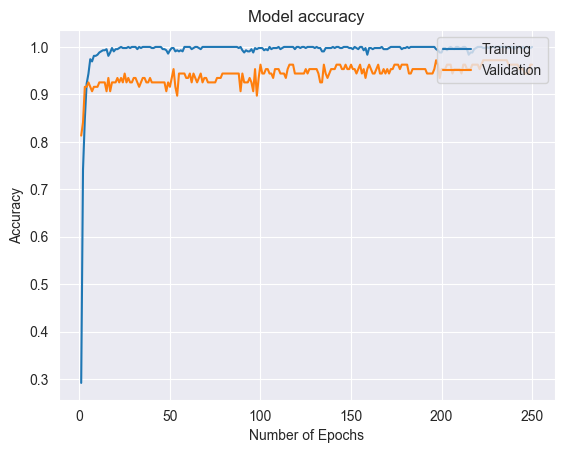

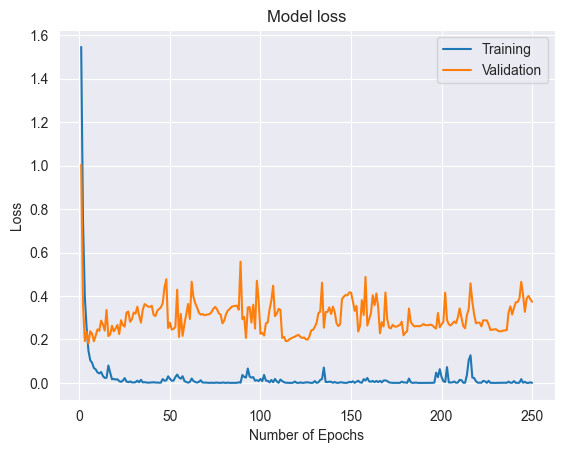

In [26]:
def plot_learningCurve(history, epochs):
    # Plotting the accuracy graph of training & validation
    epoch_range = range(1, epochs + 1)
    plt.plot(epoch_range, history.history["accuracy"])
    plt.plot(epoch_range, history.history["val_accuracy"])
    plt.title("Model accuracy")
    plt.ylabel("Accuracy")
    plt.xlabel("Number of Epochs")
    plt.legend(["Training", "Validation"], loc="upper right")
    plt.show()

    # Plotting the loss graph of training & validation
    plt.plot(epoch_range, history.history["loss"])
    plt.plot(epoch_range, history.history["val_loss"])
    plt.title("Model loss")
    plt.ylabel("Loss")
    plt.xlabel("Number of Epochs")
    plt.legend(["Training", "Validation"], loc="upper right")
    plt.show()


plot_learningCurve(history, 250)

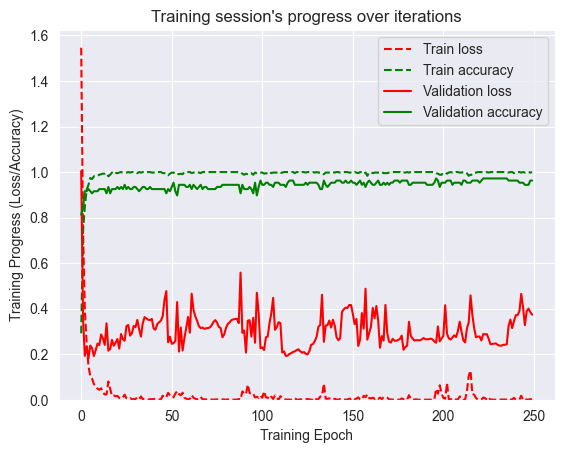

In [27]:
plt.plot(np.array(history.history["loss"]), "r--", label="Train loss")
plt.plot(np.array(history.history["accuracy"]), "g--", label="Train accuracy")
plt.plot(np.array(history.history["val_loss"]), "r-", label="Validation loss")
plt.plot(
    np.array(history.history["val_accuracy"]),
    "g-",
    label="Validation accuracy",
)
plt.title("Training session's progress over iterations")
plt.legend(loc="upper right")
plt.ylabel("Training Progress (Loss/Accuracy)")
plt.xlabel("Training Epoch")
plt.ylim(0)
plt.show()

In [28]:
def print_confusion_matrix(confusion_matrix, class_names, figsize=(10, 7), fontsize=14):
    df_cm = pd.DataFrame(confusion_matrix, index=class_names, columns=class_names)
    fig = plt.figure(figsize=figsize)
    try:
        heatmap = sns.heatmap(df_cm, annot=True, fmt="d")
    except ValueError:
        raise ValueError("Confusion matrix values must not be integers.")
    heatmap.yaxis.set_ticklabels(
        heatmap.yaxis.get_ticklabels(),
        rotation=0,
        ha="right",
        fontsize=fontsize,
    )
    heatmap.xaxis.set_ticklabels(
        heatmap.xaxis.get_ticklabels(),
        rotation=45,
        ha="right",
        fontsize=fontsize,
    )
    plt.ylabel("Truth")
    plt.xlabel("Prediction")


truth = ["Downstairs", "Jogging", "Sitting", "Standing", "Upstairs", "Walking"]
prediction = [
    "Downstairs",
    "Jogging",
    "Sitting",
    "Standing",
    "Upstairs",
    "Walking",
]

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step


(<Figure size 500x500 with 1 Axes>,
 <Axes: xlabel='predicted label', ylabel='true label'>)

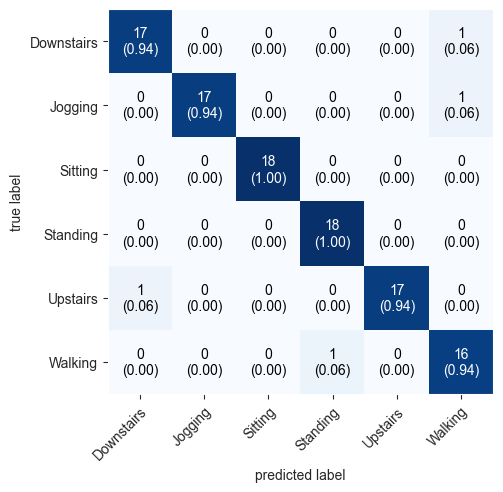

In [29]:
y_pred = np.argmax(model.predict(X_test), axis=-1)
mat = confusion_matrix(y_test, y_pred)
plot_confusion_matrix(conf_mat=mat, class_names=label.classes_, show_normed=True, figsize=(5, 5))

In [30]:
print("Precision Score : ", precision_score(y_test, y_pred, average=None))
print("Recall Score : ", recall_score(y_test, y_pred, average=None))
print("Accuracy Score :", accuracy_score(y_test, y_pred, normalize=True))
print("Loss Score :", hamming_loss(y_test, y_pred))

Precision Score :  [0.94444444 1.         1.         0.94736842 1.         0.88888889]
Recall Score :  [0.94444444 0.94444444 1.         1.         0.94444444 0.94117647]
Accuracy Score : 0.9626168224299065
Loss Score : 0.037383177570093455
